# Biodiversity EDA — Mid-Atlantic Region (MD, VA, PA)
Exploratory analysis of bird and plant occurrence records fetched from GBIF.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

DATA_DIR = Path("../data")

birds = pd.read_csv(DATA_DIR / "birds_md_va_pa.csv", parse_dates=["eventDate"])
plants = pd.read_csv(DATA_DIR / "plants_md_va_pa.csv", parse_dates=["eventDate"])

print(f"Birds : {len(birds):,} records")
print(f"Plants: {len(plants):,} records")

Matplotlib is building the font cache; this may take a moment.


Birds : 2,100 records
Plants: 2,100 records


## 1. Dataset Overview

In [2]:
for label, df in [("Birds", birds), ("Plants", plants)]:
    print(f"\n{'='*40}")
    print(f"{label} — shape: {df.shape}")
    print(df.dtypes)
    print(f"\nNull counts:")
    print(df.isnull().sum())


Birds — shape: (2100, 14)
species              object
scientificName       object
decimalLatitude     float64
decimalLongitude    float64
stateProvince        object
eventDate            object
datasetName          object
taxonRank            object
kingdom              object
phylum               object
class                object
order                object
family               object
genus                object
dtype: object

Null counts:
species             29
scientificName       0
decimalLatitude      0
decimalLongitude     0
stateProvince       38
eventDate            0
datasetName          0
taxonRank            0
kingdom              0
phylum               0
class                0
order                0
family               0
genus                2
dtype: int64

Plants — shape: (2100, 14)
species              object
scientificName       object
decimalLatitude     float64
decimalLongitude    float64
stateProvince        object
eventDate            object
datasetName          o

In [3]:
birds.head(3)

,species,scientificName,decimalLatitude,decimalLongitude,stateProvince,eventDate,datasetName,taxonRank,kingdom,phylum,class,order,family,genus
0,Cygnus buccinator,"Cygnus buccinator Richardson, 1831",38.993545,-77.949633,Virginia,2026-01-01T16:09:54,iNaturalist research-grade observations,SPECIES,Animalia,Chordata,Aves,Anseriformes,Anatidae,Cygnus
1,Ardea herodias,"Ardea herodias Linnaeus, 1758",39.446148,-76.230483,Maryland,2026-01-03T13:08:10,iNaturalist research-grade observations,SPECIES,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea
2,Branta canadensis,"Branta canadensis (Linnaeus, 1758)",38.842700,-77.060153,Virginia,2026-01-02T16:13,iNaturalist research-grade observations,SPECIES,Animalia,Chordata,Aves,Anseriformes,Anatidae,Branta


In [4]:
plants.head(3)

,species,scientificName,decimalLatitude,decimalLongitude,stateProvince,eventDate,datasetName,taxonRank,kingdom,phylum,class,order,family,genus
0,Cygnus buccinator,"Cygnus buccinator Richardson, 1831",38.993545,-77.949633,Virginia,2026-01-01T16:09:54,iNaturalist research-grade observations,SPECIES,Animalia,Chordata,Aves,Anseriformes,Anatidae,Cygnus
1,Ardea herodias,"Ardea herodias Linnaeus, 1758",39.446148,-76.230483,Maryland,2026-01-03T13:08:10,iNaturalist research-grade observations,SPECIES,Animalia,Chordata,Aves,Pelecaniformes,Ardeidae,Ardea
2,Branta canadensis,"Branta canadensis (Linnaeus, 1758)",38.842700,-77.060153,Virginia,2026-01-02T16:13,iNaturalist research-grade observations,SPECIES,Animalia,Chordata,Aves,Anseriformes,Anatidae,Branta


## 2. Species Richness — Unique Species per Dataset

Unique bird species : 161
Unique plant species: 463


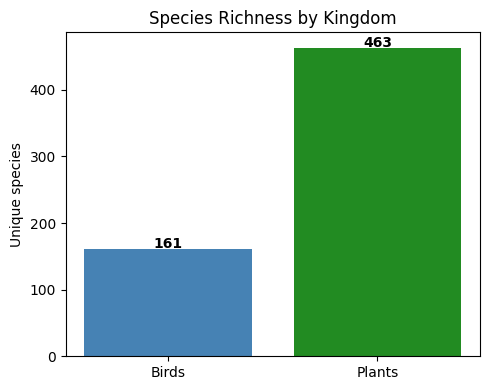

In [5]:
bird_species  = birds["species"].nunique()
plant_species = plants["species"].nunique()

print(f"Unique bird species : {bird_species}")
print(f"Unique plant species: {plant_species}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Birds", "Plants"], [bird_species, plant_species], color=["steelblue", "forestgreen"])
ax.set_ylabel("Unique species")
ax.set_title("Species Richness by Kingdom")
for i, v in enumerate([bird_species, plant_species]):
    ax.text(i, v + 1, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Observations by State

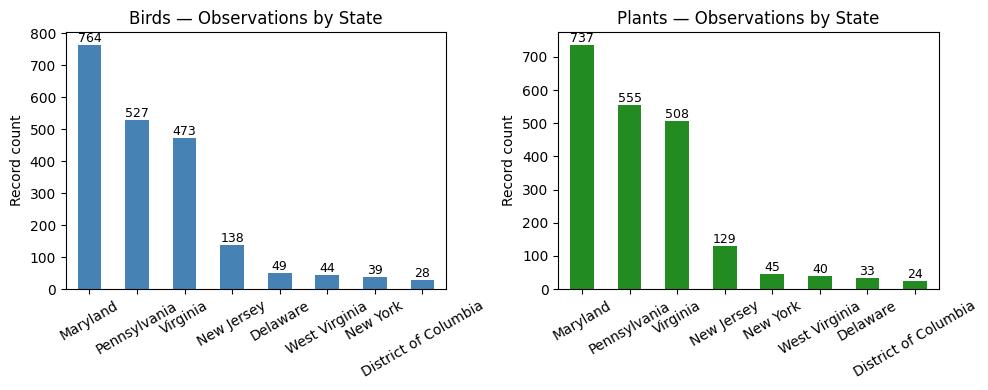

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (label, df, color) in zip(axes, [
    ("Birds",  birds,  "steelblue"),
    ("Plants", plants, "forestgreen")
]):
    counts = df["stateProvince"].value_counts()
    counts.plot(kind="bar", ax=ax, color=color)
    ax.set_title(f"{label} — Observations by State")
    ax.set_xlabel("")
    ax.set_ylabel("Record count")
    ax.tick_params(axis="x", rotation=30)
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Top 15 Most-Observed Species

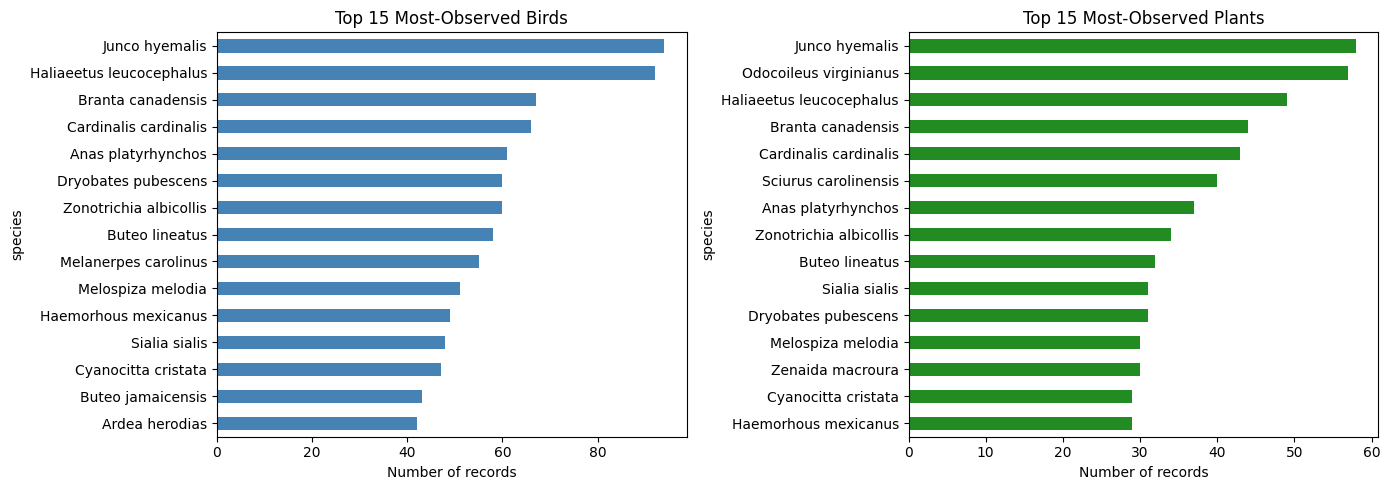

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df, color) in zip(axes, [
    ("Birds",  birds,  "steelblue"),
    ("Plants", plants, "forestgreen")
]):
    top = df["species"].value_counts().head(15)
    top.sort_values().plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Top 15 Most-Observed {label}")
    ax.set_xlabel("Number of records")

plt.tight_layout()
plt.show()

## 5. Top Families by Observation Count

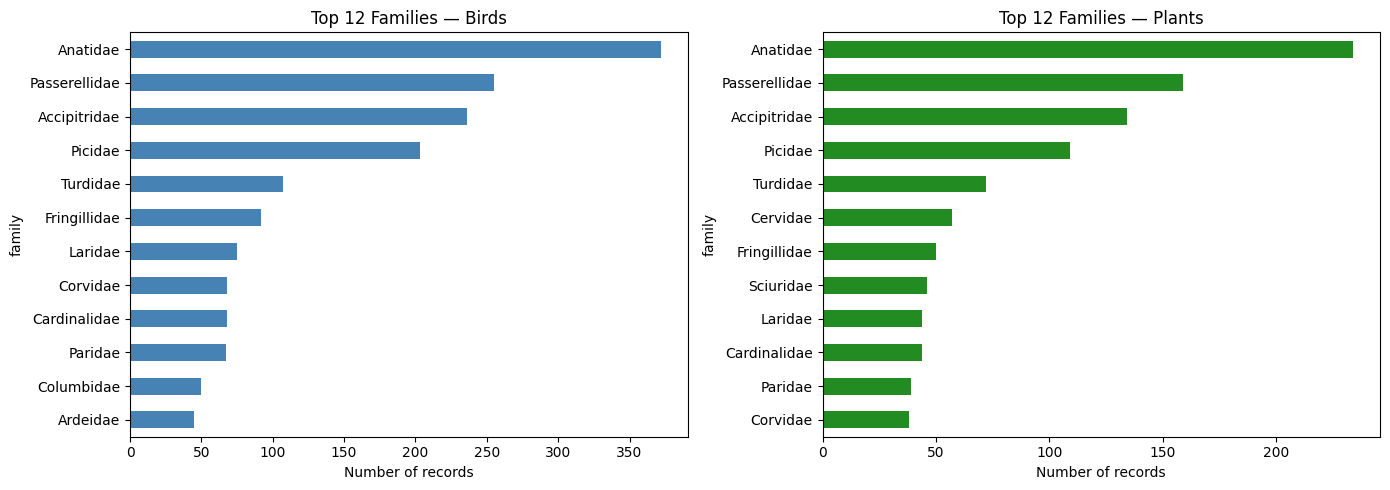

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, df, color) in zip(axes, [
    ("Birds",  birds,  "steelblue"),
    ("Plants", plants, "forestgreen")
]):
    top_fam = df["family"].value_counts().head(12)
    top_fam.sort_values().plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Top 12 Families — {label}")
    ax.set_xlabel("Number of records")

plt.tight_layout()
plt.show()

## 6. Temporal Patterns — Observations by Month

In [9]:
birds["month"]  = birds["eventDate"].dt.month
plants["month"] = plants["eventDate"].dt.month

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (label, df, color) in zip(axes, [
    ("Birds",  birds,  "steelblue"),
    ("Plants", plants, "forestgreen")
]):
    monthly = df["month"].value_counts().reindex(range(1, 13), fill_value=0)
    ax.bar(range(1, 13), monthly.values, color=color)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_title(f"{label} — Observations by Month")
    ax.set_ylabel("Record count")

plt.tight_layout()
plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

## 7. Geographic Distribution — Scatter Map

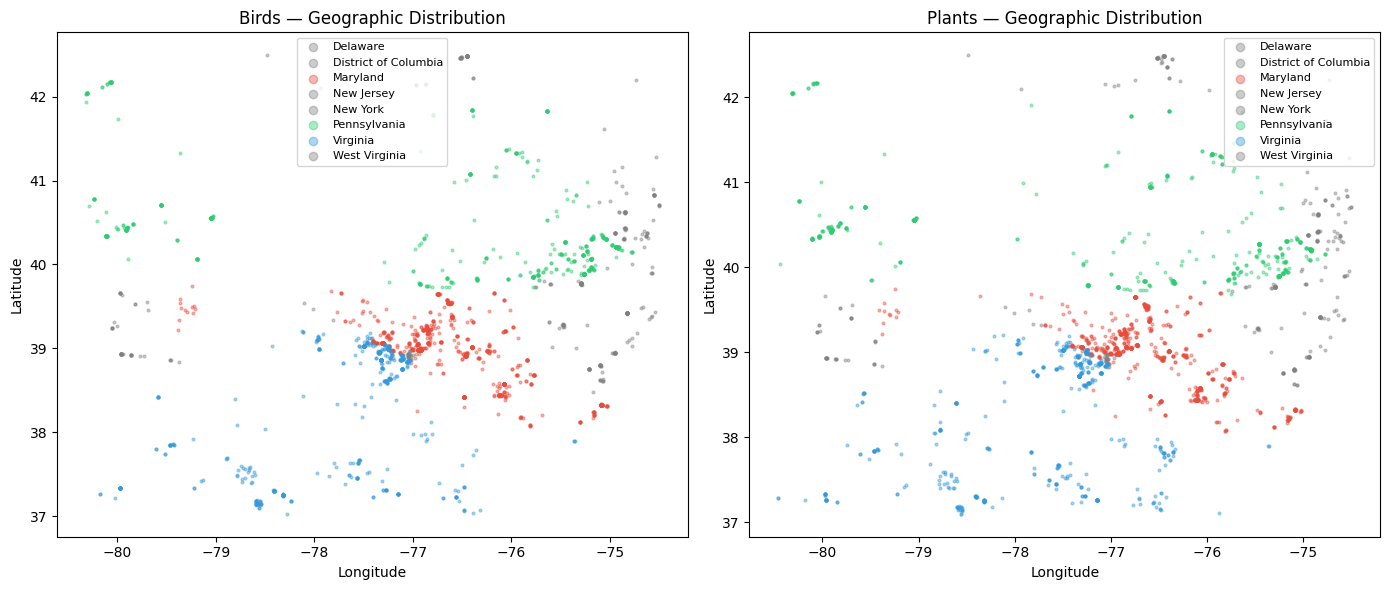

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

state_colors = {"Maryland": "#e74c3c", "Virginia": "#3498db", "Pennsylvania": "#2ecc71"}

for ax, (label, df) in zip(axes, [("Birds", birds), ("Plants", plants)]):
    for state, grp in df.groupby("stateProvince"):
        ax.scatter(
            grp["decimalLongitude"], grp["decimalLatitude"],
            s=4, alpha=0.4,
            color=state_colors.get(state, "gray"),
            label=state
        )
    ax.set_title(f"{label} — Geographic Distribution")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

## 8. Species Richness per State — Unique Species Count

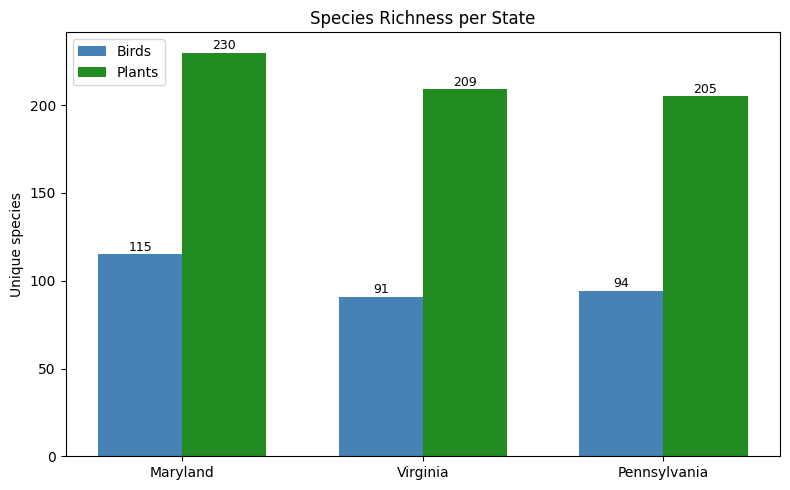

In [11]:
states = ["Maryland", "Virginia", "Pennsylvania"]

bird_richness  = {s: birds[birds["stateProvince"] == s]["species"].nunique()  for s in states}
plant_richness = {s: plants[plants["stateProvince"] == s]["species"].nunique() for s in states}

x = np.arange(len(states))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, [bird_richness[s]  for s in states], width, label="Birds",  color="steelblue")
bars2 = ax.bar(x + width/2, [plant_richness[s] for s in states], width, label="Plants", color="forestgreen")

ax.set_xticks(x)
ax.set_xticklabels(states)
ax.set_ylabel("Unique species")
ax.set_title("Species Richness per State")
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 9. Order-Level Diversity (Birds)

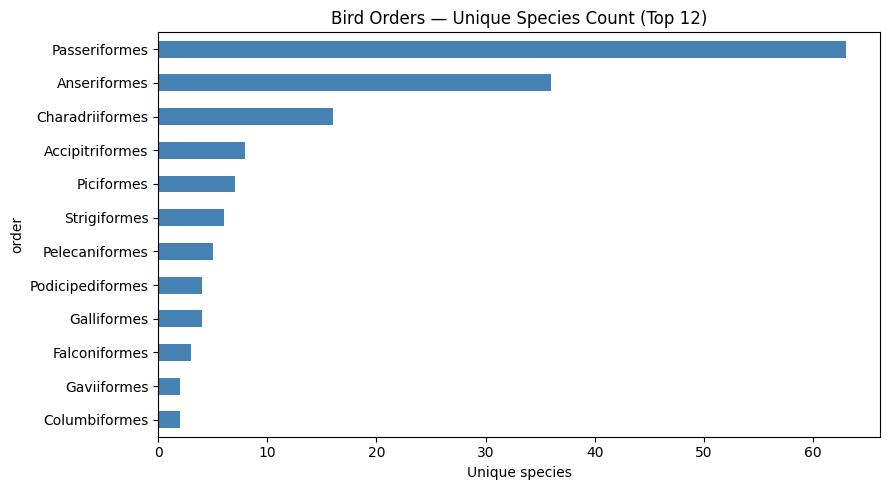

In [12]:
order_counts = birds.groupby("order")["species"].nunique().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
order_counts.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Bird Orders — Unique Species Count (Top 12)")
ax.set_xlabel("Unique species")
plt.tight_layout()
plt.show()

## 10. Plant Phylum Breakdown

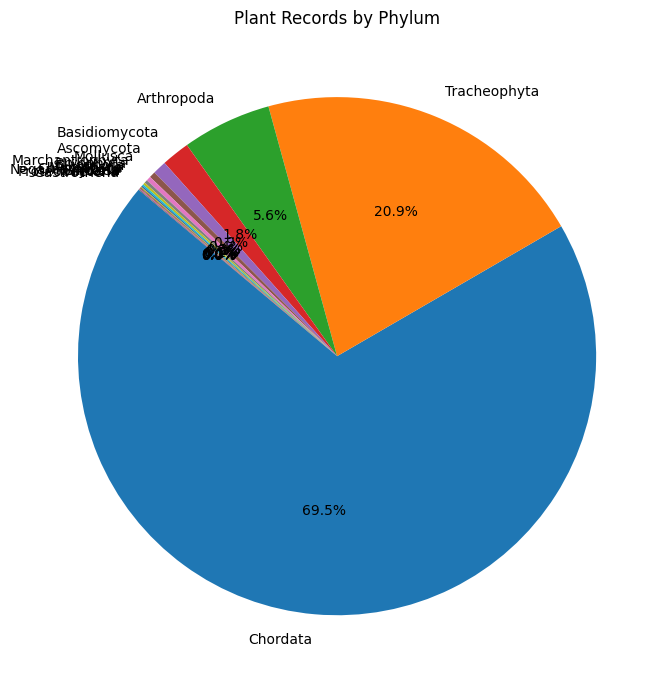

In [13]:
phylum_counts = plants["phylum"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(phylum_counts.values, labels=phylum_counts.index, autopct="%1.1f%%", startangle=140)
ax.set_title("Plant Records by Phylum")
plt.tight_layout()
plt.show()

## 11. Key Insights Summary

In [14]:
top_bird  = birds["species"].value_counts().idxmax()
top_plant = plants["species"].value_counts().idxmax()
top_bird_family  = birds["family"].value_counts().idxmax()
top_plant_family = plants["family"].value_counts().idxmax()
top_bird_order   = birds["order"].value_counts().idxmax()
most_bird_state  = birds["stateProvince"].value_counts().idxmax()
most_plant_state = plants["stateProvince"].value_counts().idxmax()
richest_bird_state  = max(bird_richness,  key=bird_richness.get)
richest_plant_state = max(plant_richness, key=plant_richness.get)
peak_bird_month  = birds["month"].value_counts().idxmax()
peak_plant_month = plants["month"].value_counts().idxmax()

print("=" * 55)
print("KEY INSIGHTS")
print("=" * 55)
print(f"\n[Records]")
print(f"  Birds : {len(birds):,} observations | {birds['species'].nunique()} unique species")
print(f"  Plants: {len(plants):,} observations | {plants['species'].nunique()} unique species")

print(f"\n[Most Observed Species]")
print(f"  Bird : {top_bird}  ({birds['species'].value_counts()[top_bird]} records)")
print(f"  Plant: {top_plant} ({plants['species'].value_counts()[top_plant]} records)")

print(f"\n[Dominant Families]")
print(f"  Birds : {top_bird_family}")
print(f"  Plants: {top_plant_family}")

print(f"\n[Most Diverse Bird Order]  {top_bird_order}")

print(f"\n[State with Most Observations]")
print(f"  Birds : {most_bird_state}")
print(f"  Plants: {most_plant_state}")

print(f"\n[State with Highest Species Richness]")
print(f"  Birds : {richest_bird_state} ({bird_richness[richest_bird_state]} unique species)")
print(f"  Plants: {richest_plant_state} ({plant_richness[richest_plant_state]} unique species)")

print(f"\n[Peak Observation Month]")
print(f"  Birds : month {peak_bird_month} ({month_labels[peak_bird_month-1]})")
print(f"  Plants: month {peak_plant_month} ({month_labels[peak_plant_month-1]})")
print("=" * 55)

KeyError: 'month'